<a href="https://colab.research.google.com/github/Patrick190508/whaleshark-mafia-island/blob/main/notebooks/MVP_Daily_Prediction_Ningaloo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Daily whale shark encounter prediction, Ningaloo Reef
**Minimum viable project: one site, one model, one honest evaluation.**

Question: given today's conditions, will at least one whale shark be sighted at Ningaloo?

- Data: OBIS human sightings matched to daily Copernicus SST, chlorophyll-a and salinity (`daily_ningaloo.csv`), peak season April–June, active seasons only.
- Target: `y` = 1 if at least one sighting that day, 0 otherwise. Days without a record count as 0 (observation-effort limitation).
- Baseline: average sighting probability per week of the season, from the training seasons.
- Model: logistic regression (Veritas Scholars, Week 4). Polynomial terms (Week 3) and a small neural network (Week 6) come after the MVP.
- Validation: training / validation / test sets split by season (time), never at random.

## 1. Data

### 1.1 Load the daily series and build the season table
One row per day of the season: environmental values of that day, day of season, week, target.

In [2]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

URL = "https://raw.githubusercontent.com/Patrick190508/whaleshark-mafia-island/main/data/daily_ningaloo.csv"
d = pd.read_csv(URL, parse_dates=["date"])

PEAK = [4, 5, 6]                                   # Ningaloo season: April–June
d = d[d["month"].isin(PEAK)].copy()
d["sday"] = d.groupby("year").cumcount() + 1       # day of season 1..91
d["week"] = (d["sday"] - 1) // 7 + 1
d["y"] = (d["sightings"] > 0).astype(int)          # target

# active seasons only (>= 20 sightings), as in the EDA
tot = d.groupby("year")["sightings"].sum()
active = tot[tot >= 20].index
d = d[d["year"].isin(active)].dropna(subset=["sst", "chl", "sss"]).copy()

# squared terms for the polynomial model (Week 3)
d["sday2"] = d["sday"] ** 2
d["sst2"]  = d["sst"] ** 2

print("seasons:", sorted(d["year"].unique()))
print("rows:", len(d), "| days with sighting:", d["y"].sum(), f"({d['y'].mean():.0%})")

seasons: [np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009)]
rows: 1092 | days with sighting: 748 (68%)


### 1.2 Train / validation / test split by season
Earliest seasons → training; later seasons → validation (to tune); most recent seasons → test (used once at the end).

In [5]:
TRAIN = list(range(2001, 2005))
VAL   = [2005, 2006]
TEST  = [2007, 2008, 2009]

train = d[d["year"].isin(TRAIN)]
val   = d[d["year"].isin(VAL)]
test  = d[d["year"].isin(TEST)]

for name, part in [("train", train), ("validation", val), ("test", test)]:
    print(f"{name:11s} seasons {part['year'].min()}–{part['year'].max()} | "
          f"days {len(part):4d} | share with sighting {part['y'].mean():.0%}")

train       seasons 2001–2004 | days  364 | share with sighting 76%
validation  seasons 2005–2006 | days  182 | share with sighting 81%
test        seasons 2007–2009 | days  273 | share with sighting 90%


## 2. Baseline

### 2.1 Weekly sighting probability from the training seasons

week
1     0.68
2     0.71
3     0.86
4     0.89
5     0.79
6     0.68
7     0.82
8     0.89
9     0.86
10    0.86
11    0.68
12    0.50
13    0.61
Name: p_week, dtype: float64


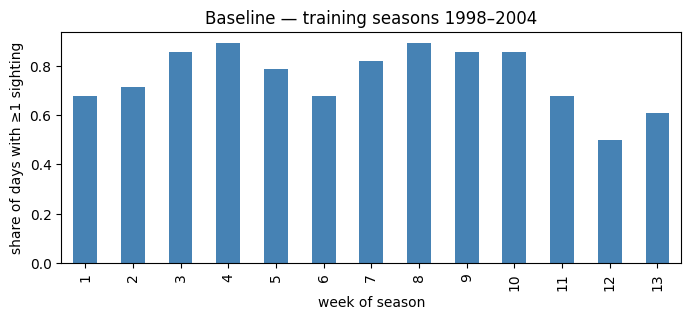

In [6]:
weekly = train.groupby("week")["y"].mean().rename("p_week")
print(weekly.round(2))

weekly.plot(kind="bar", color="steelblue", figsize=(8, 3))
plt.ylabel("share of days with ≥1 sighting"); plt.xlabel("week of season")
plt.title("Baseline — training seasons 1998–2004"); plt.show()

### 2.2 Baseline score on the validation set
Accuracy and confusion matrix when predicting 'sighting' in weeks whose probability is above 0.5.

In [7]:
from sklearn.metrics import accuracy_score, confusion_matrix

def score(y_true, p, thr=0.5, label=""):
    pred = (p >= thr).astype(int)
    acc = accuracy_score(y_true, pred)
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
    print(f"{label:22s} acc {acc:.2f} | TP {tp:3d} FP {fp:3d} FN {fn:3d} TN {tn:3d}")
    return acc

p_val_base = val["week"].map(weekly)
score(val["y"], p_val_base, label="baseline (val)")
score(val["y"], np.ones(len(val)), label="always 'yes' (val)")

baseline (val)         acc 0.81 | TP 148 FP  34 FN   0 TN   0
always 'yes' (val)     acc 0.81 | TP 148 FP  34 FN   0 TN   0


0.8131868131868132

*Reading:*

## 3. Logistic regression

### 3.1 Features and scaling
Inputs: day of season, SST, chlorophyll-a, salinity (standardised).

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

FEATS = ["sday", "sst", "chl", "sss"]

scaler = StandardScaler().fit(train[FEATS])
X_train, y_train = scaler.transform(train[FEATS]), train["y"]
X_val,   y_val   = scaler.transform(val[FEATS]),   val["y"]
X_test,  y_test  = scaler.transform(test[FEATS]),  test["y"]

### 3.2 Fit on training, probabilities on validation

In [9]:
logit = LogisticRegression(max_iter=1000).fit(X_train, y_train)
p_val_logit = logit.predict_proba(X_val)[:, 1]

score(y_val, p_val_base,  label="baseline (val)")
score(y_val, p_val_logit, label="logistic 0.5 (val)")
score(y_val, np.ones(len(val)), label="always 'yes' (val)")

baseline (val)         acc 0.81 | TP 148 FP  34 FN   0 TN   0
logistic 0.5 (val)     acc 0.77 | TP 138 FP  31 FN  10 TN   3
always 'yes' (val)     acc 0.81 | TP 148 FP  34 FN   0 TN   0


0.8131868131868132

### 3.3 Threshold tuning on the validation set
Confusion matrix for several thresholds; choose the one that balances empty trips (false positives) and missed good days (false negatives).

In [10]:
print("threshold sweep — logistic on validation")
for thr in [0.3, 0.4, 0.5, 0.6, 0.7]:
    score(y_val, p_val_logit, thr, label=f"logistic thr {thr}")

threshold sweep — logistic on validation
logistic thr 0.3       acc 0.81 | TP 148 FP  34 FN   0 TN   0
logistic thr 0.4       acc 0.81 | TP 148 FP  34 FN   0 TN   0
logistic thr 0.5       acc 0.77 | TP 138 FP  31 FN  10 TN   3
logistic thr 0.6       acc 0.74 | TP 130 FP  29 FN  18 TN   5
logistic thr 0.7       acc 0.71 | TP 116 FP  21 FN  32 TN  13


*Reading:*

### 3.4 Coefficients — which variable moves the probability

sday    0.32
chl     0.45
sss     0.49
sst     0.94
dtype: float64


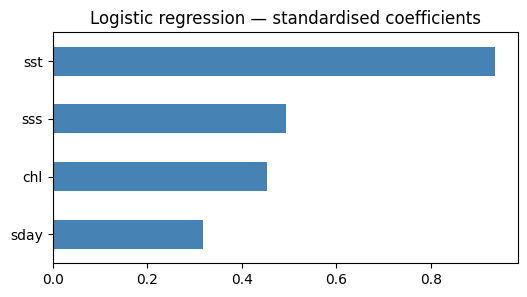

In [11]:
coef = pd.Series(logit.coef_[0], index=FEATS).sort_values()
print(coef.round(2))
coef.plot(kind="barh", color="steelblue", figsize=(6, 3))
plt.axvline(0, color="grey"); plt.title("Logistic regression — standardised coefficients"); plt.show()

*Reading:*

In [12]:
FEATS2 = ["sday", "sday2", "sst", "sst2", "chl", "sss"]
scaler2 = StandardScaler().fit(train[FEATS2])
Xtr2, Xva2, Xte2 = (scaler2.transform(p[FEATS2]) for p in (train, val, test))

logit2 = LogisticRegression(max_iter=1000).fit(Xtr2, y_train)
p_val_logit2 = logit2.predict_proba(Xva2)[:, 1]

print(pd.Series(logit2.coef_[0], index=FEATS2).round(2)); print()
for thr in [0.3, 0.4, 0.5, 0.6]:
    score(y_val, p_val_base,   thr, label=f"baseline thr {thr}")
    score(y_val, p_val_logit2, thr, label=f"poly-logistic thr {thr}")
    print()
score(y_val, np.ones(len(val)), label="always 'yes' (val)")

sday     1.09
sday2   -0.94
sst      0.41
sst2     0.32
chl      0.43
sss      0.46
dtype: float64

baseline thr 0.3       acc 0.81 | TP 148 FP  34 FN   0 TN   0
poly-logistic thr 0.3  acc 0.81 | TP 148 FP  34 FN   0 TN   0

baseline thr 0.4       acc 0.81 | TP 148 FP  34 FN   0 TN   0
poly-logistic thr 0.4  acc 0.81 | TP 148 FP  34 FN   0 TN   0

baseline thr 0.5       acc 0.81 | TP 148 FP  34 FN   0 TN   0
poly-logistic thr 0.5  acc 0.81 | TP 146 FP  33 FN   2 TN   1

baseline thr 0.6       acc 0.77 | TP 137 FP  31 FN  11 TN   3
poly-logistic thr 0.6  acc 0.77 | TP 131 FP  25 FN  17 TN   9

always 'yes' (val)     acc 0.81 | TP 148 FP  34 FN   0 TN   0


0.8131868131868132

## 4. Test (used once)

### 4.1 Baseline vs logistic regression on the test seasons

In [13]:
p_test_base  = test["week"].map(weekly)
p_test_logit2 = logit2.predict_proba(Xte2)[:, 1]
score(y_test, p_test_base,   0.3, label="baseline thr 0.3 (test)")
score(y_test, p_test_logit2, 0.3, label="poly-logistic 0.3 (test)")
score(y_test, np.ones(len(test)), label="always 'yes' (test)")

baseline thr 0.3 (test) acc 0.90 | TP 247 FP  26 FN   0 TN   0
poly-logistic 0.3 (test) acc 0.90 | TP 247 FP  26 FN   0 TN   0
always 'yes' (test)    acc 0.90 | TP 247 FP  26 FN   0 TN   0


0.9047619047619048

*Reading:*

## 5. Conclusions and next steps

*Does the model beat the calendar?*

Next steps:
1. Polynomial terms (SST²) — Week 3
2. Small neural network — Week 6
3. Add wind speed as a fast-changing variable
4. Repeat for Philippines and Tofo; cross-site test